### ANN for regression: medical insurance charge prediction

**Dataset:** [`insurance.csv`](https://www.kaggle.com/datasets/mirichoi0218/insurance) contains 1,338 insurance records. In this project I try to predict the continuous `charges` value using age, sex, BMI, number of children, smoking status, and region.

**Step 1 analysis:** I chose this dataset because the target is a continuous money value, so it fits a regression problem. It is also not time-series data. The dataset has numeric columns as well as categorical columns, which gives me a chance to practise both types of preprocessing. I expect smoking status and BMI to have a noticeable effect on the insurance charge.

#### Imports / modules

In [220]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder

import keras
from keras import layers

#### Loading the dataset

In [221]:
# Load the local dataset. charges is the continuous prediction target.
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [222]:
print(f"Dataset shape: {df.shape}")
print("\nData types:")
print(df.dtypes)

Dataset shape: (1338, 7)

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


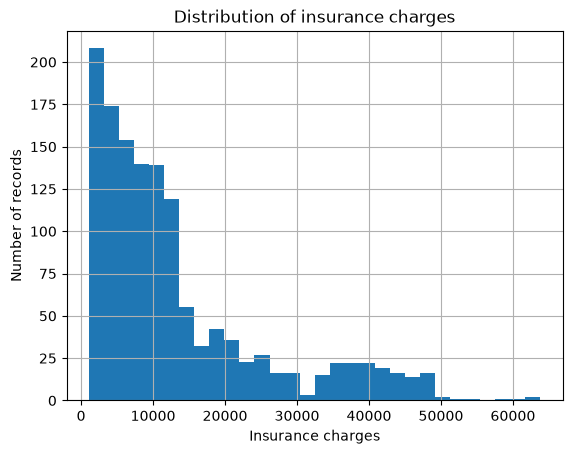

In [223]:
# Inspect the continuous target distribution.
df["charges"].hist(bins=30)
plt.xlabel("Insurance charges")
plt.ylabel("Number of records")
plt.title("Distribution of insurance charges")
plt.show()

**Step 1 analysis:** The dataset has 1,338 rows and six columns that can be used to predict the target. `age`, `bmi`, and `children` are numeric values. `sex` and `smoker` have two possible values, so I converted them into 0 and 1. `region` has four names without any natural order, so I used one-hot encoding for it.

### Step 2: Data cleaning and preparation

**Step 2 analysis:** There were no missing values in the dataset. I found one exact duplicate row and removed it. The IQR check showed some high charge and BMI values, but they looked like possible real insurance cases rather than obvious data-entry mistakes, so I kept them. I changed the two binary columns into 0/1 values and one-hot encoded `region`. After this step, all model inputs were numeric and there were 1,337 rows left.

In [224]:
# Check missing values before cleaning.
print("Missing values per column:")
print(df.isna().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


In [225]:
# Display numerical ranges and IQR-based potential outliers for inspection.
numeric_columns = ["age", "bmi", "children", "charges"]
print(df[numeric_columns].describe().T)

for column in numeric_columns:
    first_quartile = df[column].quantile(0.25)
    third_quartile = df[column].quantile(0.75)
    iqr = third_quartile - first_quartile
    lower_bound = first_quartile - 1.5 * iqr
    upper_bound = third_quartile + 1.5 * iqr
    potential_outliers = df[column].between(lower_bound, upper_bound, inclusive="both").eq(False).sum()
    print(f"{column}: {potential_outliers} potential IQR outliers")

           count          mean           std        min         25%       50%  \
age       1338.0     39.207025     14.049960    18.0000    27.00000    39.000   
bmi       1338.0     30.663397      6.098187    15.9600    26.29625    30.400   
children  1338.0      1.094918      1.205493     0.0000     0.00000     1.000   
charges   1338.0  13270.422265  12110.011237  1121.8739  4740.28715  9382.033   

                   75%          max  
age          51.000000     64.00000  
bmi          34.693750     53.13000  
children      2.000000      5.00000  
charges   16639.912515  63770.42801  
age: 0 potential IQR outliers
bmi: 9 potential IQR outliers
children: 0 potential IQR outliers
charges: 139 potential IQR outliers


### Handling the categorical variables

*Type 1: Boolean categories*

In [226]:
# Remove the single exact duplicate. No missing values were found, so no imputation is needed.
rows_before = len(df)
df = df.drop_duplicates().copy()
print(f"Removed {rows_before - len(df)} duplicate row(s).")
print(f"Cleaned dataset shape: {df.shape}")

Removed 1 duplicate row(s).
Cleaned dataset shape: (1337, 7)


In [227]:
# Inspect category frequencies to check the categorical-data balance.
for column in ["sex", "smoker", "region"]:
    print(f"\n{column}:")
    print(df[column].value_counts())


sex:
sex
male      675
female    662
Name: count, dtype: int64

smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


### Handling categorical variables

**Type 1: Binary categories**

`sex` and `smoker` each have exactly two values. They can be represented with a single $0/1$ column without losing information.

**Type 2: Ordinal categories**

There are no ordinal categories in this dataset. `children` is already numeric and its numerical value has a natural order, so it is kept unchanged.

**Type 3: Nominal categories**

`region` contains four geographic labels with no meaningful order. It must be one-hot encoded, rather than assigned arbitrary numeric labels.

In [228]:
# Map binary variables explicitly so 1 has a clear interpretation.
binary_mapping = {"female": 0, "male": 1, "no": 0, "yes": 1}
df["sex"] = df["sex"].map(binary_mapping)
df["smoker"] = df["smoker"].map(binary_mapping)

print(df[["sex", "smoker"]].head())

   sex  smoker
0    0       1
1    1       0
2    1       0
3    1       0
4    1       0


*Type 3: Nominal categories*

In [229]:
# One-hot encode the nominal region variable. drop="first" prevents redundant columns.
region_encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded_regions = region_encoder.fit_transform(df[["region"]])
encoded_region_columns = region_encoder.get_feature_names_out(["region"])
encoded_regions = pd.DataFrame(encoded_regions, columns=encoded_region_columns, index=df.index).astype(int)

df = pd.concat([df.drop(columns="region"), encoded_regions], axis=1)

In [230]:
# Confirm that preprocessing left only numeric model inputs and no missing values.
print(df.dtypes)
print(f"\nMissing values after preprocessing: {df.isna().sum().sum()}")

age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

Missing values after preprocessing: 0


In [231]:
# AI use disclosure: GitHub Copilot helped adapt the lecture example to insurance.csv.
# Prompt used: "Help me implement Steps 1-2 of an ANN regression notebook for insurance.csv."
# Final cleaned and encoded dataset for the later train/validation/test split.
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


### Step 3: Feature, target, and data splitting

In [232]:
X = df.drop(columns="charges")
y = df["charges"]

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (1337, 8)
Target: (1337,)


#### Train/test/validation -split

In [233]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Training set: (935, 8)
Validation set: (201, 8)
Test set: (201, 8)


### Step 4: Neural network structure

In [234]:
# Количество входных признаков берём из подготовленного набора данных.
input_features = X_train.shape[1]

# Используем небольшую сеть, чтобы начать с простой модели регрессии.
model = keras.Sequential(
    [
        keras.Input(shape=(input_features,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(1)
    ]
)

# Для регрессии используем MSE, а MAE добавляем для понятной оценки ошибки.
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

### Step 5: Train the neural network

In [ ]:
# Обучаем модель на тренировочных данных и проверяем её на валидационных данных.
history = model.fit(
    x=X_train,
    y=y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 305559360.0000 - mae: 13030.1982 - val_loss: 376493056.0000 - val_mae: 14332.9512
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 305285792.0000 - mae: 13020.2910 - val_loss: 376174208.0000 - val_mae: 14322.7168
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 304984288.0000 - mae: 13009.6826 - val_loss: 375790688.0000 - val_mae: 14310.3574
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 304591392.0000 - mae: 12995.2373 - val_loss: 375253920.0000 - val_mae: 14292.9453
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 304036928.0000 - mae: 12975.6758 - val_loss: 374523072.0000 - val_mae: 14269.2266
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 303271360.0000 - mae: 12948.0566 - val_loss: 373484576.0000 - val_mae: 14235.4512
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 302211008.0000 - mae: 12908.9414 - val_loss: 372065952.0000 - val_mae: 14189.1787
Epoch 8/50
30/30 ━━━

#### Training metrics in order to see if the model trained an works well

<Axes: >

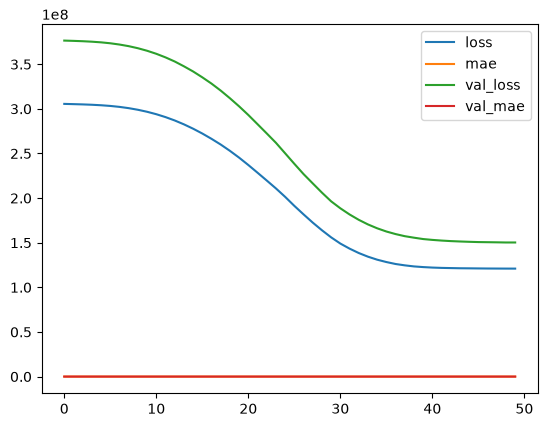

In [236]:
# let's use pandas for this (easy code)
# try to look if the model is actually training 
# => the error is going downwards
# if using validation data, you get two lines
# in this case, see if the lines follow a similar trend 
# (they don't always overlap with complex data, the trend is more important)
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [237]:
# compare the final model loss/evaluation values
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

Test data evaluation:
[146434496.0, 9216.6220703125]

Train data evaluation:
[120958816.0, 8772.9990234375]


#### Step 6: Error metrics

In [238]:
# get test predictions
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


,Test True Y,Model Predictions
0,12629.16560,15636.925781
1,5327.40025,12081.160156
2,12333.82800,16309.443359
3,9301.89355,13927.888672
4,1526.31200,9812.196289
...,...,...
196,8827.20990,14270.156250
197,14256.19280,16452.726562
198,4889.03680,12186.539062
199,4571.41305,11040.839844


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

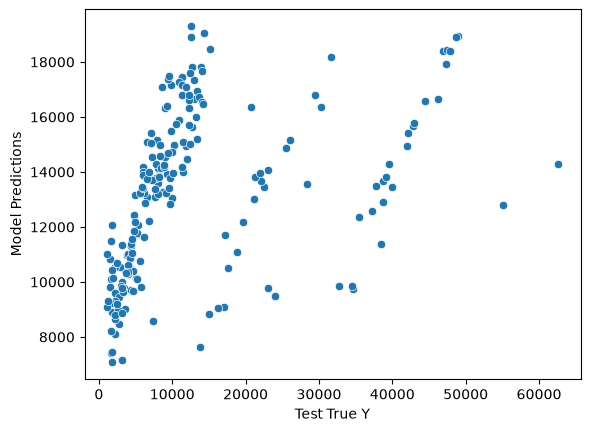

In [239]:
# these values follow a linear diagonal line = good predictions
# we basically compare the predicted values 
# to true test values and see the differences
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

In [240]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2), "$")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "$^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
9216.62 $

MSE
146434502.03 $^2

RMSE:
12101.01 $

R-squared:
0.14

Explained variance score:
0.14


**Step 6 analysis:** The test MAE was about $9,232 and the RMSE was about $12,039. These errors are quite large compared with the median charge of about $9,382, so the model is not making very precise predictions. The R-squared and explained variance scores were both about 0.15. This means the model explains only around 15% of the differences in insurance charges. The training graph shows that the model learned at first and then reached a plateau. I think the main reasons for the weak result are that the input columns were not scaled and that the network is quite small. The model probably has trouble learning the strong relationship between smoking, BMI, and charges.

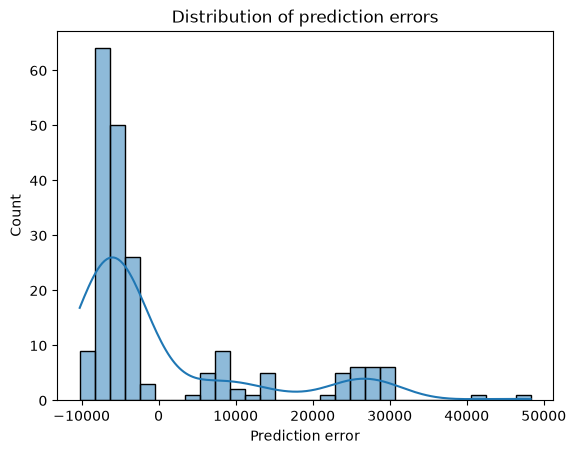

In [241]:
residuals = np.asarray(y_test) - np.asarray(test_predictions)
sns.histplot(x=residuals, bins=30, kde=True)
plt.xlabel("Prediction error")
plt.title("Distribution of prediction errors")
plt.show()
plt.close()

### Step 7: Testing the model with imaginary values

The following examples represent realistic customers. The first comparison changes only smoking status, because smoking is expected to have a strong effect on insurance charges. The second comparison changes age, BMI, and number of children while keeping the other values fixed. The predictions are compared to check whether the model responds in a logical direction.

In [242]:
# Создаём реалистичные тестовые записи с исходными категориальными значениями.
imaginary_customers = pd.DataFrame(
    [
        {"age": 30, "sex": "female", "bmi": 24.0, "children": 0, "smoker": "no", "region": "northwest"},
        {"age": 30, "sex": "female", "bmi": 24.0, "children": 0, "smoker": "yes", "region": "northwest"},
        {"age": 55, "sex": "male", "bmi": 35.0, "children": 3, "smoker": "no", "region": "northwest"},
    ]
)

# Применяем к новым данным те же преобразования, что и к обучающим данным.
imaginary_customers["sex"] = imaginary_customers["sex"].map(binary_mapping)
imaginary_customers["smoker"] = imaginary_customers["smoker"].map(binary_mapping)
new_regions = region_encoder.transform(imaginary_customers[["region"]])
new_region_columns = region_encoder.get_feature_names_out(["region"])
new_regions = pd.DataFrame(new_regions, columns=new_region_columns, index=imaginary_customers.index).astype(int)

imaginary_features = pd.concat(
    [imaginary_customers.drop(columns="region"), new_regions],
    axis=1
).reindex(columns=X.columns)

imaginary_predictions = model.predict(imaginary_features, verbose=0).reshape(-1)
results = imaginary_customers.copy()
results["predicted_charges"] = imaginary_predictions.round(2)
results

,age,sex,bmi,children,smoker,region,predicted_charges
0,30,0,24.0,0,0,northwest,10017.700195
1,30,0,24.0,0,1,northwest,10236.450195
2,55,1,35.0,3,0,northwest,17202.929688


**Step 7 analysis:** The 30-year-old non-smoker received a predicted charge of about $9,969. When I changed only the smoking status, the prediction increased to about $10,417. This is the expected direction, although the increase is smaller than I expected from looking at the original data. The older customer with a higher BMI and three children received the highest prediction, about $17,412. This also makes sense because age and BMI should affect the charge. At the same time, the low R-squared and high MAE mean that these predictions should only be treated as examples of how the model responds, not as accurate insurance prices.

### Optional final step: Simple user interface

I also added a small Tkinter window where a user can enter customer details and receive a predicted insurance charge. The window uses the same mappings and region encoder as the training data, so the new values are prepared in the same way as the original data. After running this cell, `open_insurance_ui()` can be used to open the window.

The output is only an estimate because the model's accuracy is limited.

In [248]:
def predict_customer_values(age, sex, bmi, children, smoker, region):
    customer = pd.DataFrame(
        [{
            "age": age,
            "sex": sex,
            "bmi": bmi,
            "children": children,
            "smoker": smoker,
            "region": region,
        }]
    )
    customer["sex"] = customer["sex"].map(binary_mapping)
    customer["smoker"] = customer["smoker"].map(binary_mapping)
    customer_regions = region_encoder.transform(customer[["region"]])
    customer_regions = pd.DataFrame(
        customer_regions,
        columns=region_encoder.get_feature_names_out(["region"]),
        index=customer.index,
    ).astype(int)
    customer_features = pd.concat(
        [customer.drop(columns="region"), customer_regions],
        axis=1,
    ).reindex(columns=X.columns)
    return float(model.predict(customer_features, verbose=0)[0, 0])


def open_insurance_ui():
    import tkinter as tk
    from tkinter import messagebox, ttk

    window = tk.Tk()
    window.title("Insurance Charge Predictor")
    window.resizable(False, False)

    fields = [
        ("Age", "30"),
        ("BMI", "24.0"),
        ("Children", "0"),
    ]
    entries = {}

    for row, (label, default) in enumerate(fields):
        ttk.Label(window, text=label).grid(row=row, column=0, padx=10, pady=6, sticky="w")
        entry = ttk.Entry(window, width=24)
        entry.insert(0, default)
        entry.grid(row=row, column=1, padx=10, pady=6)
        entries[label] = entry

    ttk.Label(window, text="Sex").grid(row=3, column=0, padx=10, pady=6, sticky="w")
    sex_value = tk.StringVar(value="female")
    ttk.Combobox(window, textvariable=sex_value, values=["female", "male"], state="readonly", width=21).grid(
        row=3, column=1, padx=10, pady=6
    )

    ttk.Label(window, text="Smoker").grid(row=4, column=0, padx=10, pady=6, sticky="w")
    smoker_value = tk.StringVar(value="no")
    ttk.Combobox(window, textvariable=smoker_value, values=["no", "yes"], state="readonly", width=21).grid(
        row=4, column=1, padx=10, pady=6
    )

    ttk.Label(window, text="Region").grid(row=5, column=0, padx=10, pady=6, sticky="w")
    region_value = tk.StringVar(value="northwest")
    ttk.Combobox(
        window,
        textvariable=region_value,
        values=["northeast", "northwest", "southeast", "southwest"],
        state="readonly",
        width=21,
    ).grid(row=5, column=1, padx=10, pady=6)

    result = ttk.Label(window, text="Enter values and select Predict", width=38)
    result.grid(row=7, column=0, columnspan=2, padx=10, pady=10)

    def calculate_prediction():
        try:
            prediction = predict_customer_values(
                age=float(entries["Age"].get()),
                sex=sex_value.get(),
                bmi=float(entries["BMI"].get()),
                children=float(entries["Children"].get()),
                smoker=smoker_value.get(),
                region=region_value.get(),
            )
            result.config(text=f"Predicted charge: ${prediction:,.2f}")
        except (TypeError, ValueError):
            messagebox.showerror("Invalid input", "Age, BMI, and children must be numeric.")

    ttk.Button(window, text="Predict", command=calculate_prediction).grid(
        row=6, column=0, columnspan=2, padx=10, pady=10
    )
    window.mainloop()

In [249]:
open_insurance_ui()

### Step 8: Final personal analysis

In this project I went through the main steps of creating a regression neural network. I selected a dataset, checked its columns, removed a duplicate row, converted the text categories into numbers, split the data, created a Dense network, trained it, and checked its predictions. During training, the model made predictions for the training examples and compared them with the real insurance charges. It then adjusted its weights to reduce the error.

The data preparation was not too difficult after I understood the columns. The most important thing was not to treat `region` as an ordered number, because the region names do not have a ranking. One-hot encoding was more suitable. I found the training graph slightly confusing at first because MSE is much larger than MAE, so the MAE lines looked almost flat when they were plotted together.

The final model did learn some general patterns, but its performance was not very strong. The R-squared value was about 0.15 and the MAE was about 9,232, which means that the predictions can be far from the real charges. The scatter plot also showed that the model predicted mostly around the middle values and underestimated the most expensive cases. Because of this, I would not use this exact model to decide real insurance prices.

Regression can be useful in working life for estimating prices, costs, demand, salaries, energy use, and medical expenses. For example, an insurance company could use a model to make an initial estimate, while a human would still check the final decision. The model would need to be tested regularly because the data and customer patterns can change.

The main improvement I would try next is scaling the input features before training. I would also try a wider network and compare the result with the current model. Separating the MSE and MAE plots would make the training process easier to understand. These changes might help the network learn the effect of smoking and BMI more clearly.

I used generative AI to help adapt the lecture examples to this insurance dataset, write parts of the preprocessing and model code, and explain the results. I checked the code by running the cells, looking at the outputs, checking the metrics, and testing the model with new example customers.